In [2]:
import pandas as pd

df = pd.read_csv('../data/my_dataset.csv')
df.head()

,OyuncuID,Dogum_Tarihi,Yas,Kayit_Tarihi,Son_Giris,Ilkbahar_Saati,Yaz_Saati,Sonbahar_Saati,Kis_Saati,Toplam_Saat,OyuncuSeviyesi,Churn_Durumu,Hesap_Yasi
0,1000,1999-03-28,27,2025-05-01,2025-08-30,14,54,0,0,69,16,1,1.18
1,1001,1985-11-18,40,2025-06-02,2026-04-27,30,54,46,43,174,26,1,1.09
2,1002,1971-07-12,54,2023-08-10,2024-05-16,37,12,44,45,140,23,1,2.90
3,1003,2004-06-07,22,2024-06-06,2025-06-18,47,183,45,45,322,35,1,2.08
4,1004,2005-07-03,21,2026-05-01,2026-06-28,15,49,0,0,65,16,0,0.18


In [3]:
df.isnull().sum()

OyuncuID          0
Dogum_Tarihi      0
Yas               0
Kayit_Tarihi      0
Son_Giris         0
Ilkbahar_Saati    0
Yaz_Saati         0
Sonbahar_Saati    0
Kis_Saati         0
Toplam_Saat       0
OyuncuSeviyesi    0
Churn_Durumu      0
Hesap_Yasi        0
dtype: int64

In [4]:
df.describe()

,OyuncuID,Yas,Ilkbahar_Saati,Yaz_Saati,Sonbahar_Saati,Kis_Saati,Toplam_Saat,OyuncuSeviyesi,Churn_Durumu,Hesap_Yasi
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5999.50000,22.411800,45.210900,80.15970,44.240000,48.266300,218.81720,24.810700,0.808100,1.435732
std,2886.89568,11.083966,42.271223,101.88383,46.953137,46.953639,218.18174,15.390158,0.393815,1.067361
min,1000.00000,11.000000,0.000000,0.00000,0.000000,0.000000,0.00000,1.000000,0.000000,0.100000
25%,3499.75000,12.000000,4.000000,0.00000,0.000000,0.000000,35.00000,11.000000,1.000000,0.380000
50%,5999.50000,20.000000,40.000000,49.00000,40.000000,43.000000,129.00000,22.000000,1.000000,1.290000
75%,8499.25000,30.000000,88.000000,112.00000,90.000000,89.000000,382.00000,39.000000,1.000000,2.560000
max,10999.00000,60.000000,143.000000,476.00000,141.000000,140.000000,887.00000,59.000000,1.000000,3.000000


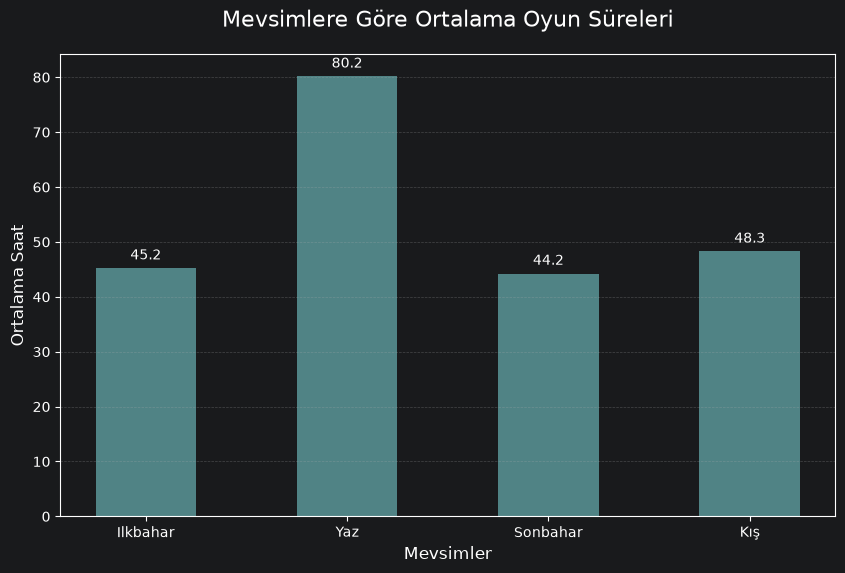

In [5]:
import matplotlib.pyplot as plt

# Mevsimleri sıralayalım
mevsimler = ['Ilkbahar', 'Yaz', 'Sonbahar', 'Kış']

# Mevsimsel ortalamaları alalım
mevsimlik_ortalamalar = [
    df['Ilkbahar_Saati'].mean(),
    df['Yaz_Saati'].mean(),
    df['Sonbahar_Saati'].mean(),
    df['Kis_Saati'].mean()
]

plt.figure(figsize=(10, 6))


bars = plt.bar(mevsimler, mevsimlik_ortalamalar, color='#5F9EA0', alpha=0.8, width=0.5)


plt.title('Mevsimlere Göre Ortalama Oyun Süreleri', fontsize=16, pad=20)
plt.ylabel('Ortalama Saat', fontsize=12)
plt.xlabel('Mevsimler', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 1), ha='center', va='bottom', fontsize=10)

plt.show()

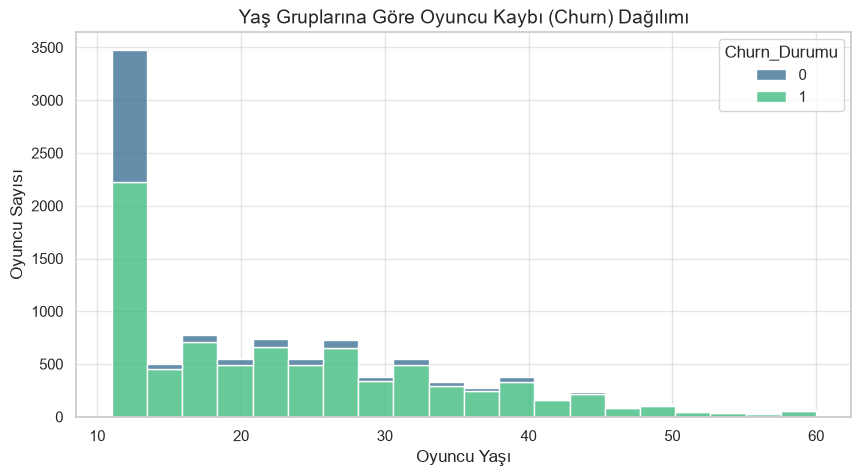

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin daha şık görünmesi için seaborn teması
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

# x parametresini 'Yas' olarak güncelledik
sns.histplot(data=df, x='Yas', hue='Churn_Durumu',
             multiple='stack',
             palette='viridis',
             bins=20)

plt.title('Yaş Gruplarına Göre Oyuncu Kaybı (Churn) Dağılımı', fontsize=14)
plt.xlabel('Oyuncu Yaşı')
plt.ylabel('Oyuncu Sayısı')
plt.show()

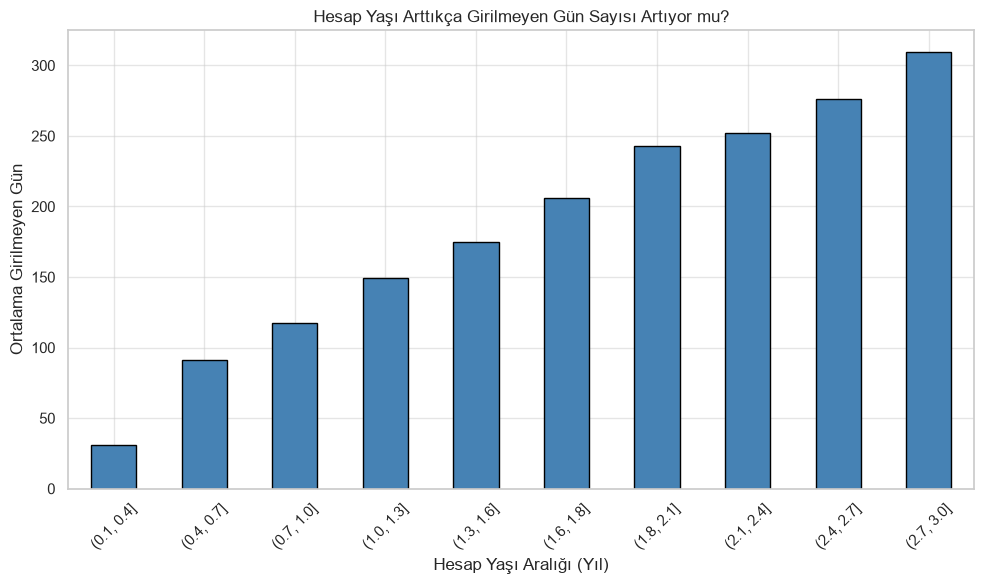

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/my_dataset.csv")  # yolunuzu kendinize göre ayarlayın

# Girilmeyen gün sayısını hesapla
df["Son_Giris"] = pd.to_datetime(df["Son_Giris"])
bugun = pd.Timestamp.now()
df["Girilmeyen_Gun"] = (bugun - df["Son_Giris"]).dt.days

# Hesap yaşını gruplara ayır (precision=0 ile aralık sınırları tam sayıya yuvarlanır)
df["Hesap_Yasi_Grup"] = pd.cut(df["Hesap_Yasi"], bins=10, precision=0)
grup_ortalama = df.groupby("Hesap_Yasi_Grup", observed=True)["Girilmeyen_Gun"].mean()

# Sütun grafik
plt.figure(figsize=(10, 6))
grup_ortalama.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Hesap Yaşı Arttıkça Girilmeyen Gün Sayısı Artıyor mu?")
plt.xlabel("Hesap Yaşı Aralığı (Yıl)")
plt.ylabel("Ortalama Girilmeyen Gün")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
